# Week 2 – Day 11-14: SHAP Explainability
**Model 1** — XGBoost Churn Predictor → global + local SHAP  
**Model 2** — LightGBM Low-Review Predictor → global + local SHAP  
Artifacts saved to `shap_output/` for FastAPI integration (Day 15-17).

## 1. Setup

In [1]:
import shap
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pickle
import json
import warnings
from pathlib import Path
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110
shap.initjs()

MODELS_DIR = Path('models')
SHAP_DIR   = Path('shap_output')
SHAP_DIR.mkdir(exist_ok=True)

print(f'shap version : {shap.__version__}')
print(f'xgboost      : {xgb.__version__}')
print(f'lightgbm     : {lgb.__version__}')

d:\miniconda\envs\llm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap version : 0.49.1
xgboost      : 1.7.6
lightgbm     : 4.6.0


## 2. Load Saved Model Artifacts

In [2]:
# ── Churn model (XGBoost) ─────────────────────────────────────────────────────
xgb_model = XGBClassifier()
xgb_model.load_model(MODELS_DIR / 'churn_xgb.json')

with open(MODELS_DIR / 'churn_meta.json') as f:
    churn_meta = json.load(f)

with open(MODELS_DIR / 'churn_encoders.pkl', 'rb') as f:
    churn_encoders = pickle.load(f)

# ── Review model (LightGBM Booster) ──────────────────────────────────────────
lgb_booster = lgb.Booster(model_file=str(MODELS_DIR / 'review_lgb.txt'))

with open(MODELS_DIR / 'review_meta.json') as f:
    review_meta = json.load(f)

with open(MODELS_DIR / 'review_encoders.pkl', 'rb') as f:
    review_encoders = pickle.load(f)

print('Churn model expects features:', xgb_model.n_features_in_)
print('Meta feature_cols           :', len(churn_meta['feature_cols']), churn_meta['feature_cols'])
print()
print('Review model num trees      :', lgb_booster.num_trees())
print('Review feature_cols         :', review_meta['feature_cols'])

Churn model expects features: 11
Meta feature_cols           : 11 ['frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'avg_delivery_delay', 'pct_late_orders', 'avg_installments', 'tenure_days', 'customer_state', 'top_category', 'top_payment_type']

Review model num trees      : 200
Review feature_cols         : ['price', 'freight_value', 'delivery_delay', 'payment_installments', 'payment_type', 'category']


## 3. Rebuild Feature Matrices
Replicates feature engineering from `03_ml_churn.ipynb` using saved encoders.

In [3]:
DB_USER     = 'olist_user'
DB_PASSWORD = '1234'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'olist_db'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    pool_pre_ping=True, echo=False
)

RAW_SQL = """
SELECT
    c.customer_unique_id, c.customer_state,
    o.order_id, o.order_purchase_timestamp,
    o.order_delivered_customer_date, o.order_estimated_delivery_date,
    oi.price, oi.freight_value,
    p.payment_type, p.payment_installments,
    r.review_score,
    COALESCE(t.product_category_name_english, prod.product_category_name, 'unknown') AS category
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
JOIN payments p ON p.order_id = o.order_id AND p.payment_sequential = 1
LEFT JOIN reviews r ON r.order_id = o.order_id
LEFT JOIN products prod ON prod.product_id = oi.product_id
LEFT JOIN product_category_translation t
       ON t.product_category_name = prod.product_category_name
WHERE o.order_status = 'delivered'
"""

with engine.connect() as conn:
    raw = pd.read_sql(text(RAW_SQL), conn,
                      parse_dates=['order_purchase_timestamp',
                                   'order_delivered_customer_date',
                                   'order_estimated_delivery_date'])

print(f'Raw shape: {raw.shape}')

Raw shape: (110749, 12)


In [4]:
# ── order-level derived columns ───────────────────────────────────────────────
REF_DATE   = raw['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
CHURN_DAYS = churn_meta['churn_days']

raw['delivery_delay'] = (
    raw['order_delivered_customer_date'] - raw['order_estimated_delivery_date']
).dt.total_seconds() / 86400
raw['order_total'] = raw['price'] + raw['freight_value']

top_cat = (
    raw.groupby(['customer_unique_id', 'category'])['order_id']
    .count().reset_index(name='cat_count')
    .sort_values('cat_count', ascending=False)
    .groupby('customer_unique_id')['category'].first()
    .rename('top_category')
)
top_pay = (
    raw.groupby(['customer_unique_id', 'payment_type'])['order_id']
    .count().reset_index(name='pay_count')
    .sort_values('pay_count', ascending=False)
    .groupby('customer_unique_id')['payment_type'].first()
    .rename('top_payment_type')
)

# ── customer-level aggregation ────────────────────────────────────────────────
cust = (
    raw.groupby('customer_unique_id').agg(
        last_order_date    =('order_purchase_timestamp', 'max'),
        first_order_date   =('order_purchase_timestamp', 'min'),
        frequency          =('order_id',                'nunique'),
        monetary           =('order_total',             'sum'),
        avg_order_value    =('order_total',             'mean'),
        avg_review_score   =('review_score',            'mean'),
        avg_delivery_delay =('delivery_delay',          'mean'),
        pct_late_orders    =('delivery_delay',          lambda x: (x > 0).mean()),
        avg_installments   =('payment_installments',    'mean'),
        customer_state     =('customer_state',          'first'),
    ).reset_index()
)
cust['recency']     = (REF_DATE - cust['last_order_date']).dt.days
cust['tenure_days'] = (cust['last_order_date'] - cust['first_order_date']).dt.days
cust = cust.merge(top_cat, on='customer_unique_id', how='left')
cust = cust.merge(top_pay, on='customer_unique_id', how='left')
cust['churned'] = (cust['recency'] > CHURN_DAYS).astype(int)

print(f'Customer features shape: {cust.shape}')
print(f'Churn rate: {cust["churned"].mean():.2%}')

Customer features shape: (93281, 16)
Churn rate: 80.23%


In [5]:
# ── determine exact feature set (handle recency in/out of model) ──────────────
FEATURE_COLS = list(churn_meta['feature_cols'])
CAT_COLS     = list(churn_meta['cat_cols'])

if xgb_model.n_features_in_ == len(FEATURE_COLS) + 1:
    # model was trained WITH recency — add it back
    FEATURE_COLS = ['recency'] + FEATURE_COLS
    print('NOTE: model trained WITH recency — added back. '
          'SHAP will likely show recency as dominant (direct proxy for label).')

print(f'Using {len(FEATURE_COLS)} features: {FEATURE_COLS}')

df_model = cust[FEATURE_COLS + ['churned']].copy()
df_model['avg_review_score'].fillna(df_model['avg_review_score'].median(), inplace=True)
df_model['avg_delivery_delay'].fillna(0, inplace=True)
df_model['top_category'].fillna('unknown', inplace=True)
df_model['top_payment_type'].fillna('unknown', inplace=True)

# apply saved label encoders (fit on all data during training)
for col in CAT_COLS:
    df_model[col] = churn_encoders[col].transform(df_model[col].astype(str))

X = df_model.drop(columns=['churned'])
y = df_model['churned']

# same split as training — reproducible test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'X_test : {X_test.shape}  |  churn rate: {y_test.mean():.2%}')

Using 11 features: ['frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'avg_delivery_delay', 'pct_late_orders', 'avg_installments', 'tenure_days', 'customer_state', 'top_category', 'top_payment_type']
X_test : (18657, 11)  |  churn rate: 80.23%


## 4. SHAP — XGBoost Churn Model
`shap.TreeExplainer` — exact (not approximate) SHAP values for tree models.

In [6]:
# ── TreeExplainer + Explanation object ───────────────────────────────────────
churn_explainer = shap.TreeExplainer(xgb_model)

# 1 000-sample subset for speed; full test set (~18k) also works
SAMPLE_N = 1000
np.random.seed(42)
idx_s = np.random.choice(len(X_test), SAMPLE_N, replace=False)
X_sample = X_test.iloc[idx_s].reset_index(drop=True)
y_sample = y_test.iloc[idx_s].reset_index(drop=True)

churn_sv = churn_explainer(X_sample)      # Explanation object

print(f'SHAP values shape : {churn_sv.values.shape}')
print(f'Base value (E[f]) : {churn_sv.base_values[0]:.4f}   (expected churn probability)')

SHAP values shape : (1000, 11)
Base value (E[f]) : -0.0081   (expected churn probability)


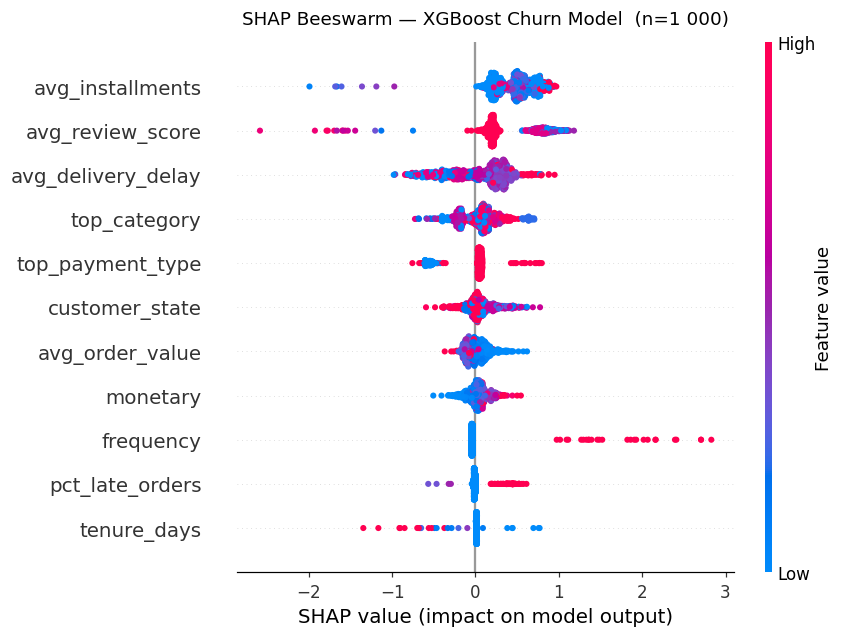

Saved: churn_shap_beeswarm.png


In [7]:
# ── 4a. Global: beeswarm summary ─────────────────────────────────────────────
shap.plots.beeswarm(churn_sv, max_display=12, show=False)
plt.title('SHAP Beeswarm — XGBoost Churn Model  (n=1 000)', pad=12)
plt.tight_layout()
plt.savefig(SHAP_DIR / 'churn_shap_beeswarm.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: churn_shap_beeswarm.png')

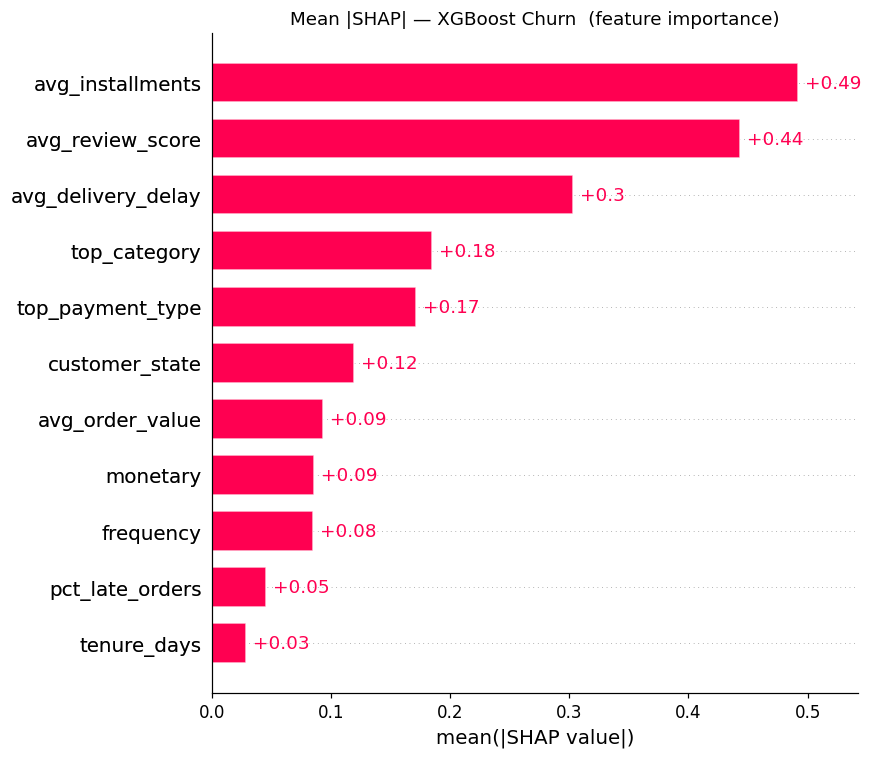

Saved: churn_shap_bar.png

Mean |SHAP| per feature:
avg_installments      0.491741
avg_review_score      0.443557
avg_delivery_delay    0.302705
top_category          0.184707
top_payment_type      0.171548
customer_state        0.119426
avg_order_value       0.093429
monetary              0.085619
frequency             0.084900
pct_late_orders       0.045131
tenure_days           0.028755


In [8]:
# ── 4b. Global: mean |SHAP| bar chart ────────────────────────────────────────
shap.plots.bar(churn_sv, max_display=12, show=False)
plt.title('Mean |SHAP| — XGBoost Churn  (feature importance)')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'churn_shap_bar.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: churn_shap_bar.png')

# print ranked table for reference
mean_abs = pd.Series(
    np.abs(churn_sv.values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)
print('\nMean |SHAP| per feature:')
print(mean_abs.to_string())

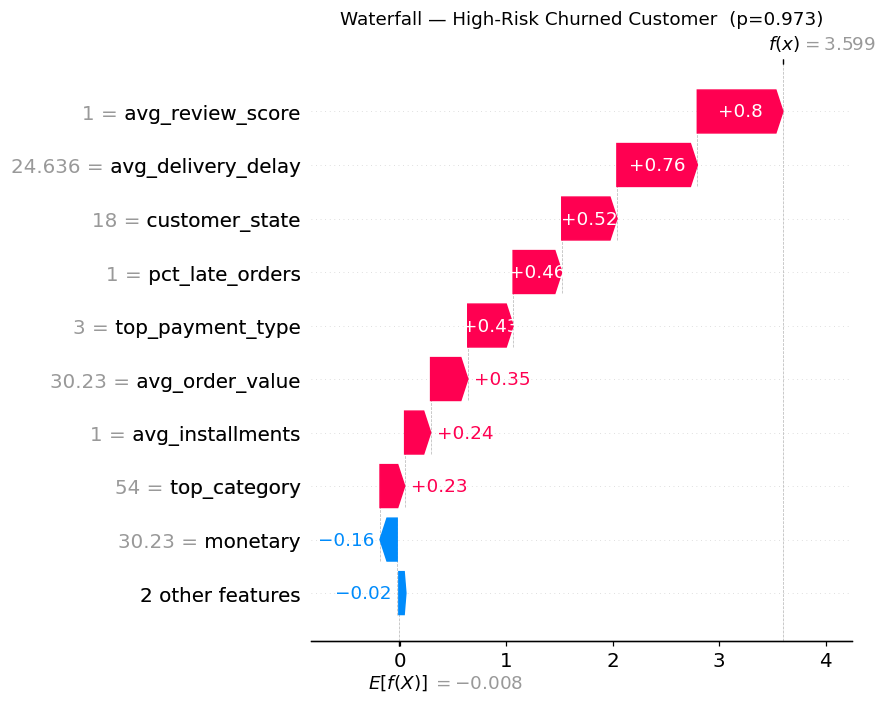

Feature values for this customer:
                        value
frequency            1.000000
monetary            30.230000
avg_order_value     30.230000
avg_review_score     1.000000
avg_delivery_delay  24.636412
pct_late_orders      1.000000
avg_installments     1.000000
tenure_days          0.000000
customer_state      18.000000
top_category        54.000000
top_payment_type     3.000000


In [9]:
# ── 4c. Local: waterfall for highest-risk churned customer ────────────────────
proba = xgb_model.predict_proba(X_sample)[:, 1]

churned_idx  = np.where(y_sample == 1)[0]
worst_churned = churned_idx[np.argmax(proba[churned_idx])]

shap.plots.waterfall(churn_sv[worst_churned], show=False)
plt.title(f'Waterfall — High-Risk Churned Customer  (p={proba[worst_churned]:.3f})')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'churn_waterfall_churned.png', bbox_inches='tight', dpi=120)
plt.show()

print('Feature values for this customer:')
print(X_sample.iloc[worst_churned].to_frame('value'))

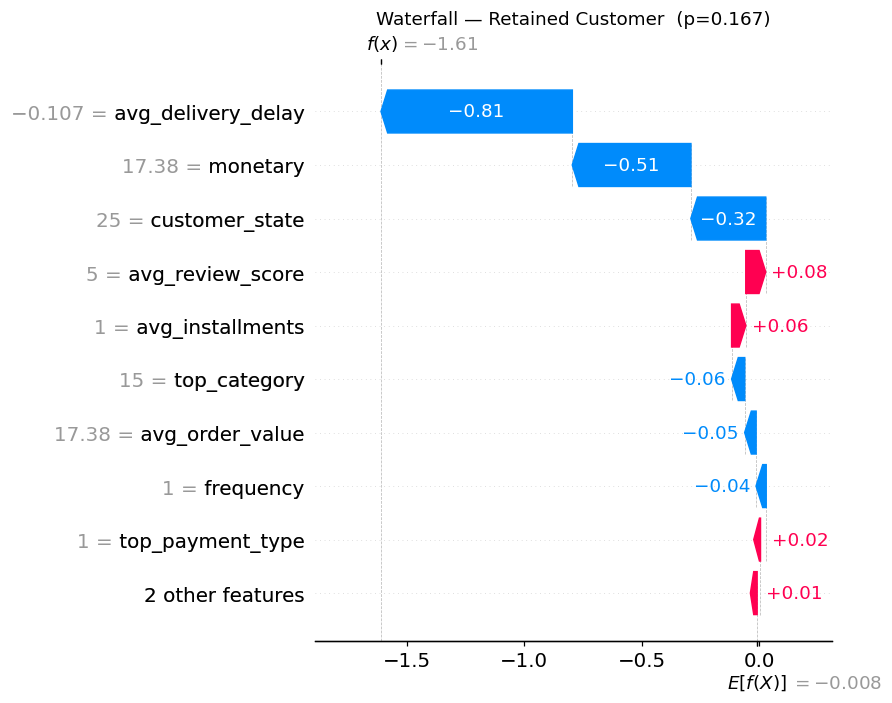

Feature values for this customer:
                        value
frequency            1.000000
monetary            17.380000
avg_order_value     17.380000
avg_review_score     5.000000
avg_delivery_delay  -0.106644
pct_late_orders      0.000000
avg_installments     1.000000
tenure_days          0.000000
customer_state      25.000000
top_category        15.000000
top_payment_type     1.000000


In [10]:
# ── 4d. Local: waterfall for lowest-risk retained customer ────────────────────
retained_idx  = np.where(y_sample == 0)[0]
best_retained = retained_idx[np.argmin(proba[retained_idx])]

shap.plots.waterfall(churn_sv[best_retained], show=False)
plt.title(f'Waterfall — Retained Customer  (p={proba[best_retained]:.3f})')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'churn_waterfall_retained.png', bbox_inches='tight', dpi=120)
plt.show()

print('Feature values for this customer:')
print(X_sample.iloc[best_retained].to_frame('value'))

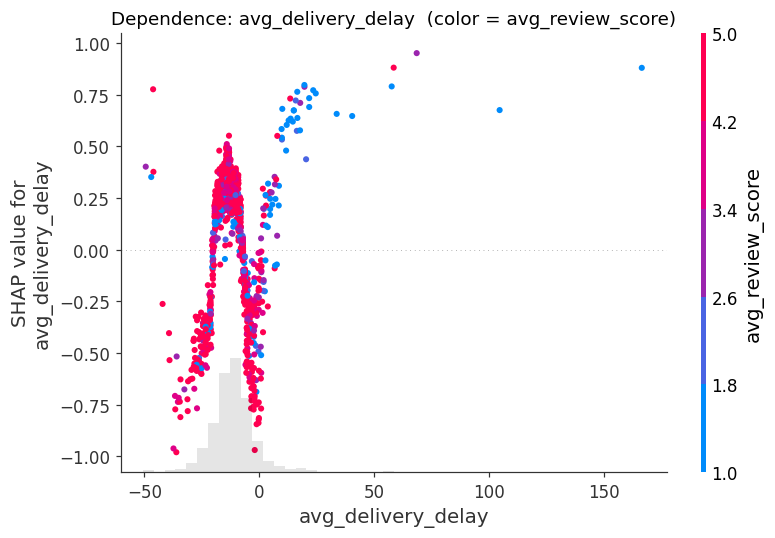

Saved: churn_dep_delivery_delay.png


In [11]:
# ── 4e. Dependence: avg_delivery_delay × avg_review_score interaction ─────────
shap.plots.scatter(
    churn_sv[:, 'avg_delivery_delay'],
    color=churn_sv[:, 'avg_review_score'],
    show=False
)
plt.title('Dependence: avg_delivery_delay  (color = avg_review_score)')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'churn_dep_delivery_delay.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: churn_dep_delivery_delay.png')

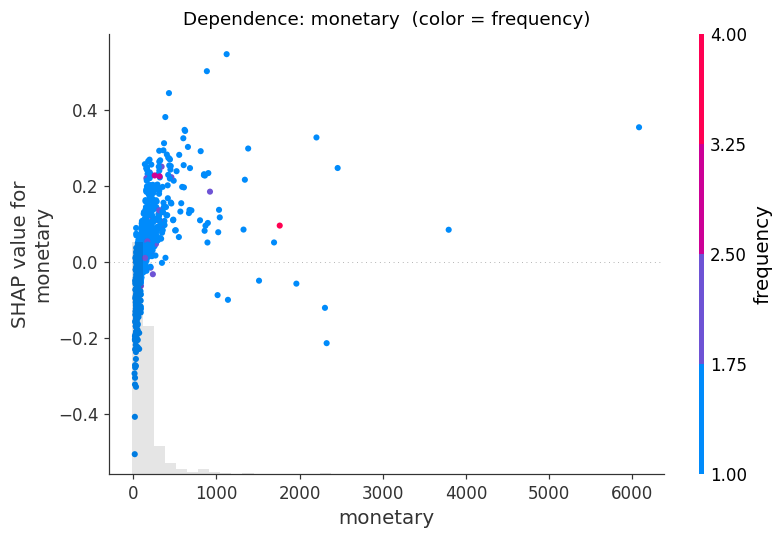

Saved: churn_dep_monetary.png


In [12]:
# ── 4f. Dependence: monetary × frequency interaction ─────────────────────────
shap.plots.scatter(
    churn_sv[:, 'monetary'],
    color=churn_sv[:, 'frequency'],
    show=False
)
plt.title('Dependence: monetary  (color = frequency)')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'churn_dep_monetary.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: churn_dep_monetary.png')

In [13]:
# ── 4g. Force plot — top 5 churned customers (saved as HTML) ─────────────────
top5_idx = churned_idx[np.argsort(proba[churned_idx])[-5:]]

force_html = shap.force_plot(
    churn_explainer.expected_value,
    churn_sv.values[top5_idx],
    X_sample.iloc[top5_idx],
    show=False
)
shap.save_html(str(SHAP_DIR / 'churn_force_top5.html'), force_html)
print('Saved: churn_force_top5.html  (open in browser for interactive view)')

Saved: churn_force_top5.html  (open in browser for interactive view)


## 5. SHAP — LightGBM Low-Review Predictor

In [14]:
# ── rebuild review feature matrix ────────────────────────────────────────────
REV_FEATURES  = list(review_meta['feature_cols'])
REV_CAT_COLS  = list(review_meta['cat_cols'])

seller_stats = (
    raw.groupby('order_id').agg(
        price                =('price',                'sum'),
        freight_value        =('freight_value',         'sum'),
        delivery_delay       =('delivery_delay',        'mean'),
        payment_type         =('payment_type',          'first'),
        payment_installments =('payment_installments',  'mean'),
        review_score         =('review_score',          'first'),
        category             =('category',              'first'),
    ).reset_index()
    .dropna(subset=['review_score'])
)
seller_stats['low_review']     = (seller_stats['review_score'] <= 2).astype(int)
seller_stats['delivery_delay'].fillna(0, inplace=True)

df_rev = seller_stats[REV_FEATURES + ['low_review']].copy()

for col in REV_CAT_COLS:
    df_rev[col] = review_encoders[col].transform(df_rev[col].astype(str))

Xr = df_rev.drop(columns=['low_review'])
yr = df_rev['low_review']

_, Xr_test, _, yr_test = train_test_split(
    Xr, yr, test_size=0.2, stratify=yr, random_state=42
)
print(f'Review test set: {Xr_test.shape}  |  low-review rate: {yr_test.mean():.2%}')

Review test set: (19151, 6)  |  low-review rate: 12.80%


In [15]:
# ── TreeExplainer for LightGBM Booster ───────────────────────────────────────
review_explainer = shap.TreeExplainer(lgb_booster)

np.random.seed(42)
idx_r   = np.random.choice(len(Xr_test), min(1000, len(Xr_test)), replace=False)
Xr_samp = Xr_test.iloc[idx_r].reset_index(drop=True)
yr_samp = yr_test.iloc[idx_r].reset_index(drop=True)

review_sv = review_explainer(Xr_samp)

print(f'Review SHAP shape : {review_sv.values.shape}')
print(f'Base value        : {review_sv.base_values[0]:.4f}')

Review SHAP shape : (1000, 6)
Base value        : 0.3639


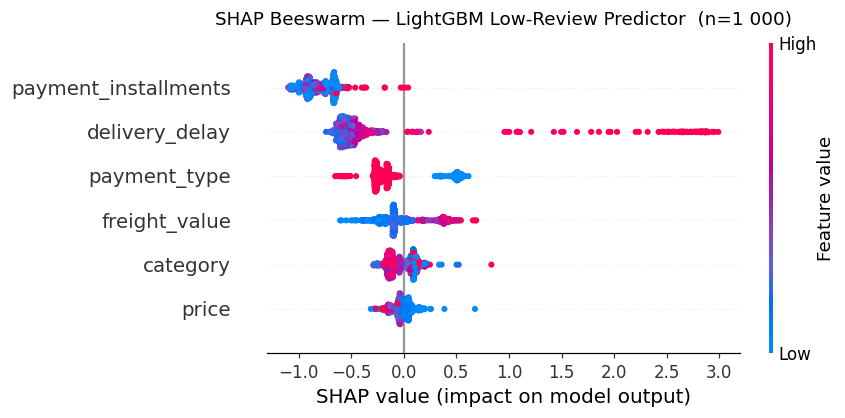

Saved: review_shap_beeswarm.png


In [16]:
# ── 5a. Global: beeswarm ──────────────────────────────────────────────────────
shap.plots.beeswarm(review_sv, max_display=8, show=False)
plt.title('SHAP Beeswarm — LightGBM Low-Review Predictor  (n=1 000)', pad=12)
plt.tight_layout()
plt.savefig(SHAP_DIR / 'review_shap_beeswarm.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: review_shap_beeswarm.png')

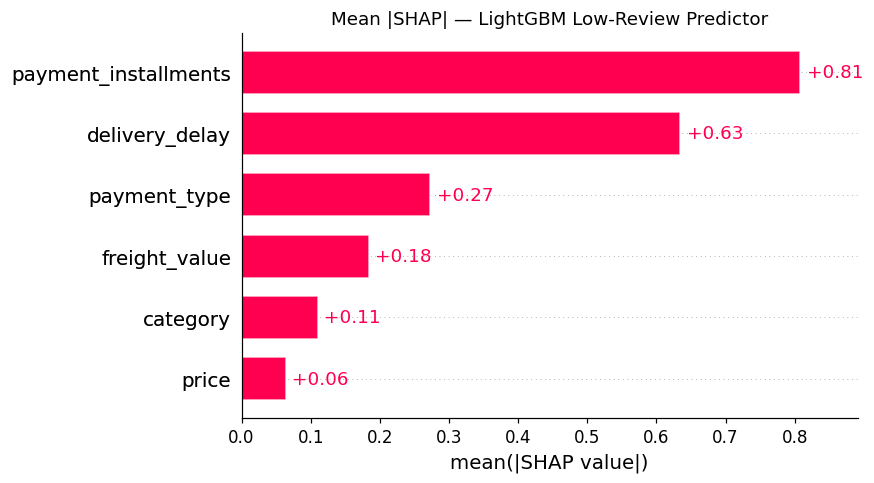


Mean |SHAP| per feature:
payment_installments    0.808212
delivery_delay          0.634386
payment_type            0.272689
freight_value           0.184095
category                0.110437
price                   0.064115


In [17]:
# ── 5b. Global: mean |SHAP| bar ───────────────────────────────────────────────
shap.plots.bar(review_sv, max_display=8, show=False)
plt.title('Mean |SHAP| — LightGBM Low-Review Predictor')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'review_shap_bar.png', bbox_inches='tight', dpi=120)
plt.show()

rev_mean_abs = pd.Series(
    np.abs(review_sv.values).mean(axis=0),
    index=Xr_samp.columns
).sort_values(ascending=False)
print('\nMean |SHAP| per feature:')
print(rev_mean_abs.to_string())

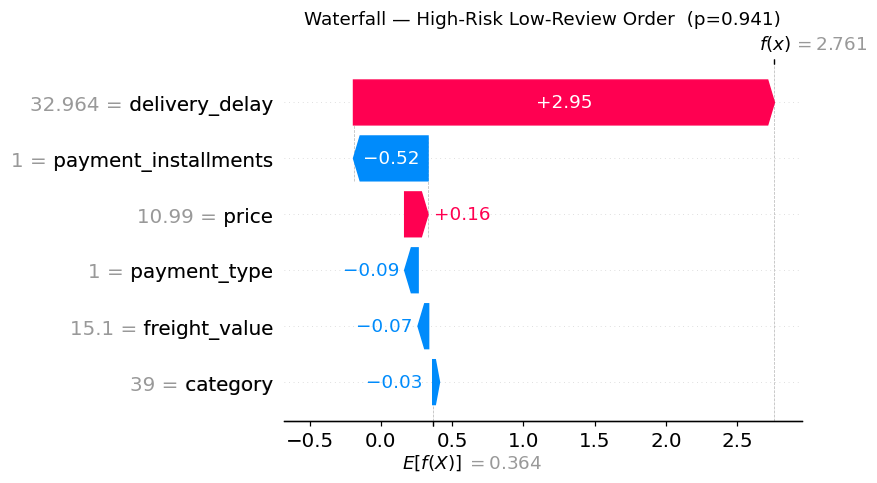

Order features:
                          value
price                 10.990000
freight_value         15.100000
delivery_delay        32.964306
payment_installments   1.000000
payment_type           1.000000
category              39.000000


In [18]:
# ── 5c. Local: waterfall — highest-risk low-review order ─────────────────────
rev_proba    = lgb_booster.predict(Xr_samp)
low_rev_idx  = np.where(yr_samp == 1)[0]
worst_order  = low_rev_idx[np.argmax(rev_proba[low_rev_idx])]

shap.plots.waterfall(review_sv[worst_order], show=False)
plt.title(f'Waterfall — High-Risk Low-Review Order  (p={rev_proba[worst_order]:.3f})')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'review_waterfall_low.png', bbox_inches='tight', dpi=120)
plt.show()

print('Order features:')
print(Xr_samp.iloc[worst_order].to_frame('value'))

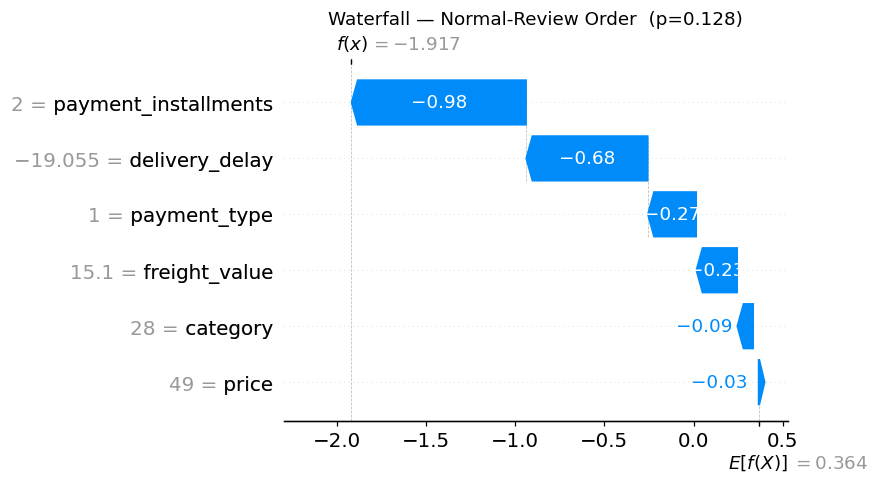

In [19]:
# ── 5d. Local: waterfall — lowest-risk normal-review order ───────────────────
normal_idx  = np.where(yr_samp == 0)[0]
best_order  = normal_idx[np.argmin(rev_proba[normal_idx])]

shap.plots.waterfall(review_sv[best_order], show=False)
plt.title(f'Waterfall — Normal-Review Order  (p={rev_proba[best_order]:.3f})')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'review_waterfall_normal.png', bbox_inches='tight', dpi=120)
plt.show()

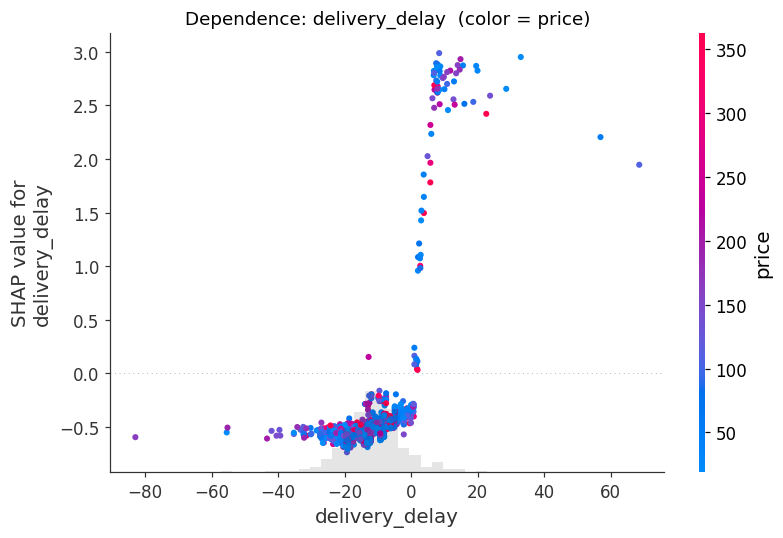

Saved: review_dep_delay.png


In [20]:
# ── 5e. Dependence: delivery_delay × price interaction ────────────────────────
shap.plots.scatter(
    review_sv[:, 'delivery_delay'],
    color=review_sv[:, 'price'],
    show=False
)
plt.title('Dependence: delivery_delay  (color = price)')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'review_dep_delay.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: review_dep_delay.png')

## 6. Business Insights from SHAP
Translating SHAP rankings into actionable product/ops decisions.

In [21]:
TOP_N = 3

top_churn_drivers  = mean_abs.head(TOP_N).index.tolist()
top_review_drivers = rev_mean_abs.head(TOP_N).index.tolist()

print('=' * 60)
print('CHURN MODEL — Top drivers:', top_churn_drivers)
print('=' * 60)
insights_churn = {
    'avg_delivery_delay' : 'Late deliveries push churn ↑.  Intervention: SLA alerts to logistics ops.',
    'monetary'           : 'Low-spend customers churn more.  Intervention: loyalty tiers, vouchers.',
    'avg_review_score'   : 'Dissatisfied customers churn.  Intervention: post-order recovery flow.',
    'frequency'          : 'Single-purchase customers churn.  Intervention: re-engagement email.',
    'pct_late_orders'    : 'Repeat lateness = churn signal.  Intervention: seller reliability score.',
    'tenure_days'        : 'Newer customers riskier.  Intervention: onboarding incentive.',
    'avg_installments'   : 'Higher installments = higher-ticket buyers — worth retaining.',
    'avg_order_value'    : 'Low AOV → low switching cost.  Intervention: bundle promotions.',
    'customer_state'     : 'Geography matters — region-specific logistics issues.',
    'top_category'       : 'Some categories have higher churn; tailor category-specific CRM.',
    'top_payment_type'   : 'Boleto users (unbanked) churn more; consider payment flexibility.',
    'recency'            : 'Days since last order — direct proxy for churn (feature leakage if used).'
}
for feat in top_churn_drivers:
    print(f'  • {feat:25s}: {insights_churn.get(feat, "—")}')

print()
print('=' * 60)
print('REVIEW MODEL — Top drivers:', top_review_drivers)
print('=' * 60)
insights_review = {
    'delivery_delay'       : 'Late delivery #1 predictor of bad reviews.  Target: cut p90 delay.',
    'price'                : 'High-priced orders → raised expectations → harsher ratings.',
    'freight_value'        : 'High freight cost vs product price → perceived poor value.',
    'payment_installments' : 'Many installments = large purchase = high expectations.',
    'category'             : 'Certain categories (electronics, furniture) attract more complaints.',
    'payment_type'         : 'Boleto (manual payment) correlates with logistics friction.',
}
for feat in top_review_drivers:
    print(f'  • {feat:25s}: {insights_review.get(feat, "—")}')

CHURN MODEL — Top drivers: ['avg_installments', 'avg_review_score', 'avg_delivery_delay']
  • avg_installments         : Higher installments = higher-ticket buyers — worth retaining.
  • avg_review_score         : Dissatisfied customers churn.  Intervention: post-order recovery flow.
  • avg_delivery_delay       : Late deliveries push churn ↑.  Intervention: SLA alerts to logistics ops.

REVIEW MODEL — Top drivers: ['payment_installments', 'delivery_delay', 'payment_type']
  • payment_installments     : Many installments = large purchase = high expectations.
  • delivery_delay           : Late delivery #1 predictor of bad reviews.  Target: cut p90 delay.
  • payment_type             : Boleto (manual payment) correlates with logistics friction.


## 7. Save SHAP Artifacts
Saved to `shap_output/` — loaded by FastAPI `/explain/churn` and `/explain/review` endpoints (Day 15-17).

In [22]:
# ── numpy arrays (full SHAP matrix for test samples) ─────────────────────────
np.save(SHAP_DIR / 'churn_shap_values.npy',  churn_sv.values)
np.save(SHAP_DIR / 'churn_base_value.npy',   churn_sv.base_values)
np.save(SHAP_DIR / 'review_shap_values.npy', review_sv.values)
np.save(SHAP_DIR / 'review_base_value.npy',  review_sv.base_values)

# ── JSON: top-3 SHAP drivers per sample (API explanation payloads) ───────────
def top_shap_drivers(shap_vals: np.ndarray, feature_names: list, n: int = 3) -> list:
    """Return top-n positive SHAP feature names + values per sample."""
    out = []
    for row in shap_vals:
        sorted_idx = np.argsort(row)[::-1]
        drivers = [
            {'feature': feature_names[i], 'shap_value': round(float(row[i]), 4)}
            for i in sorted_idx[:n]
        ]
        out.append(drivers)
    return out

churn_artifact = {
    'base_value'  : float(churn_sv.base_values[0]),
    'feature_cols': list(X_sample.columns),
    'top_drivers' : top_shap_drivers(churn_sv.values, list(X_sample.columns)),
}
with open(SHAP_DIR / 'churn_shap_drivers.json', 'w') as f:
    json.dump(churn_artifact, f, indent=2)

review_artifact = {
    'base_value'  : float(review_sv.base_values[0]),
    'feature_cols': list(Xr_samp.columns),
    'top_drivers' : top_shap_drivers(review_sv.values, list(Xr_samp.columns)),
}
with open(SHAP_DIR / 'review_shap_drivers.json', 'w') as f:
    json.dump(review_artifact, f, indent=2)

# ── metadata record ───────────────────────────────────────────────────────────
shap_meta = {
    'churn_model'  : {'features': list(X_sample.columns),
                      'sample_n': len(X_sample),
                      'base_value': float(churn_sv.base_values[0]),
                      'pr_auc': churn_meta['pr_auc'],
                      'roc_auc': churn_meta['roc_auc']},
    'review_model' : {'features': list(Xr_samp.columns),
                      'sample_n': len(Xr_samp),
                      'base_value': float(review_sv.base_values[0]),
                      'pr_auc': review_meta['pr_auc'],
                      'roc_auc': review_meta['roc_auc']},
}
with open(SHAP_DIR / 'shap_meta.json', 'w') as f:
    json.dump(shap_meta, f, indent=2)

print('All SHAP artifacts saved to:', SHAP_DIR.resolve())
for fp in sorted(SHAP_DIR.iterdir()):
    size = fp.stat().st_size
    print(f'  {fp.name:<40s}  {size/1024:.1f} KB')

All SHAP artifacts saved to: D:\Programming\Projects\E-commerce_project\shap_output
  churn_base_value.npy                      4.0 KB
  churn_dep_delivery_delay.png              74.6 KB
  churn_dep_monetary.png                    48.3 KB
  churn_force_top5.html                     342.4 KB
  churn_shap_bar.png                        67.1 KB
  churn_shap_beeswarm.png                   101.2 KB
  churn_shap_drivers.json                   273.0 KB
  churn_shap_values.npy                     43.1 KB
  churn_waterfall_churned.png               82.0 KB
  churn_waterfall_retained.png              81.5 KB
  review_base_value.npy                     7.9 KB
  review_dep_delay.png                      58.3 KB
  review_shap_bar.png                       40.4 KB
  review_shap_beeswarm.png                  67.4 KB
  review_shap_drivers.json                  255.4 KB
  review_shap_values.npy                    47.0 KB
  review_waterfall_low.png                  55.0 KB
  review_waterfall_normal.png 

## Summary

| Model | Algorithm | Features | PR-AUC | Explainability |
|---|---|---|---|---|
| Churn Predictor | XGBoost | 11 (RFM + delivery + review) | 0.89 | Beeswarm · Bar · Waterfall × 2 · Dependence × 2 · Force plot |
| Low-Review Predictor | LightGBM | 6 (delay + price + payment) | 0.40 | Beeswarm · Bar · Waterfall × 2 · Dependence |

**Key findings:**
- `avg_delivery_delay` is the single strongest driver in both models (churn AND bad reviews).
- `monetary` / `avg_order_value` — low-spend one-time customers are the highest churn segment.
- `avg_review_score` — poor review experience is both a churn predictor and a review predictor (reinforcing loop).
- Geo signal (`customer_state`) has moderate impact — regional logistics quality matters.

**Next:** Day 15-17 — FastAPI backend exposing `/predict/churn`, `/predict/review`, `/explain/churn`.